### Entity Embedding MLP
---------------------------------
#### Pipeline:

- Adatbetöltés és Felosztás
	- Kezdeti lépések: Szükséges Python és PyTorch csomagok betöltése, majd a nyers adatok beolvasása a megadott parquet fájlból.

	- Célváltozó: A predikció tárgya a Sikeres (TARGET) változó.

	- Adatfelosztás: Az adathalmaz szétválasztása egy tanító-validációs (Train-Val) és egy, a folyamat legvégéig teljesen elzárt Teszt halmazra.

	- Stratifikáció: A felosztás a Stratify változó arányainak megőrzésével történik minden halmazon (Train, Val, Test), biztosítva a reprezentatív eloszlást.

- Adatelőkészítés és Transzformáció (ColumnTransformer)
	- Adatszivárgás megelőzése: A transzformációk (illesztés/fit) szigorúan csak az aktuális tanító halmazon történnek meg, a validációs és teszt halmazokra csak alkalmazzuk (transform) azokat.

	- Numerikus változók: StandardScaler segítségével skálázzuk őket.

	- Kategorikus változók (Driver_Overtaker, Driver_Passed, Team_Passed, Team_Overtaker, Location, SXDescription-ök): OrdinalEncoder kódolja őket indexekké. Az ismeretlen (Out-of-Vocabulary) kategóriákat a rendszer -1-es értékkel kezeli, majd egy globális +1-es eltolással minden kategóriaindex pozitívvá válik. Így a 0-s index fenntartva marad a speciális/ismeretlen elemek számára az Embedding rétegben.

	- Tenzor konverzió: Az adatok PyTorch FloatTensor (numerikus) és LongTensor (kategorikus) formátumba, majd a GPU-ra (vagy CPU-ra) kerülnek, végül a DataLoader batch-ekbe szervezi őket.

- Modell Architektúra (EntityEmbeddingMLP)
	- Kategorikus változók kezelése: Minden kategória egy saját, dinamikusan méretezett Entity Embedding rétegen (sűrű vektoron) halad át, megőrizve a karakteres azonosítók (Driver/Team) belső összefüggéseit.

	- Hálózat felépítése: A numerikus értékek és a beágyazott (embedded) kategóriák egyetlen vektorrá fűzve lépnek be a klasszikus MLP (Multi-Layer Perceptron) blokkba.

	- Aktiváció és Regularizáció: A rejtett rétegekben LeakyReLU aktivációs függvényt és Dropout regularizációt alkalmazunk. A súlyok inicializálása választható (Xavier vagy Kaiming).

	- Kimenet: A kimeneti réteg egy Sigmoid függvény, amely 0 és 1 közötti valószínűséget ad vissza.

	- Veszteségfüggvény: Bináris Kereszt-Entrópia (nn.BCELoss), amely dinamikusan kiszámolt osztálysúllyal (Class Weight) bünteti a kisebbségi osztály (a Sikeres célváltozó) tévesztéseit a kiegyensúlyozatlanság miatt.

- Hiperparaméter-hangolás (Random Search & K-Fold CV)
	- Keresési stratégia: ParameterSampler segítségével Random Search iterációkat futtatunk az alábbi téren: rétegek és neuronok száma, tanulási ráta (LR), optimalizáló algoritmus (Adam/RMSprop), batch méret, dropout arány, L2 regularizáció, súlyok inicializálási metódusa.

	- Keresztvalidáció: Minden beállításcsomagot 3-szoros, stratifikált K-Fold keresztvalidációval (StratifiedKFold) tesztelünk a Train-Val halmazon.

	- Tanítási korlátok a foldokon belül: Fix maximális epoch szám, beépített Early Stoppinggal, amely megszakítja a tanítást, ha a validációs hiba nem javul.

	- Kiválasztás: A legjobb paramétercsomagot a foldokon mért legalacsonyabb átlagos validációs veszteség (Average Validation Loss) alapján választjuk ki.

- Végső Modell Tanítása
	- Újraosztás: A Train-Val halmaz felbontása egy végső tanító és egy végső validációs (Early Stopping) halmazra.

	- Dinamikus LR finomhangolás: ReduceLROnPlateau scheduler alkalmazása, amely automatikusan csökkenti a tanulási rátát, ha a validációs veszteség csökkenése megáll.

	- Modell mentése (Checkpointing): A tanítás során az eddigi legkisebb validációs veszteséget elérő epoch súlyait a rendszer azonnal kimenti egy .pth fájlba.

- Kiértékelés és Vizualizáció
	- Súlyok visszatöltése: A tesztelés megkezdése előtt a elmentett legjobb modellállapot (best weights) visszatöltése a memóriába.

	- Tesztelés: A modell futtatása a mindvégig izoláltan tartott Teszt halmazon. A predikciós valószínűségek osztályokká alakításához küszöbérték (threshold) optimalizálást végzünk a validációs halmazon F1-score maximalizálása alapján.

	- Metrikák mentése JSON fájlba: Paraméterek száma, Keresztvalidációs Accuracy átlaga és szórása (cv_acc_mean, cv_acc_std), Teszt Accuracy, F1-score, ROC AUC, Brier-score, és a Konfúziós Mátrix (Confusion Matrix).

	- Vizuális riportok (PNG mentés a dataset névvel):

	- ROC-görbe a predikciós képesség ábrázolására.

	- Kalibrációs görbe a valószínűségek megbízhatóságának ellenőrzésére.

	- Tanulási görbék (Learning Curves), amelyek az epochonkénti tanító és validációs veszteség alakulását mutatják.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split, StratifiedKFold, ParameterSampler
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, brier_score_loss, confusion_matrix, roc_curve
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve
from scipy.stats import uniform, loguniform
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import random
import copy

In [2]:
# MELYIKET HASZNÁLOD ???

#df = pd.read_parquet('C:/Users/tobakbalazs/egyetem/ELTE/IV/01_Szakdolgozat/Python_R/models/final_clean_delta_2laps.parquet')
#DATASET_NAME = 'delta'

#df = pd.read_parquet('C:/Users/tobakbalazs/egyetem/ELTE/IV/01_Szakdolgozat/Python_R/models/final_allvars_2laps.parquet')
#DATASET_NAME = 'allvars'

df = pd.read_parquet('C:/Users/tobakbalazs/egyetem/ELTE/IV/01_Szakdolgozat/Python_R/models/final_allvars_character_2laps.parquet')
DATASET_NAME = 'all_char_vars_to_entity'

In [3]:
SEED = 42
TARGET = 'Sikeres'
#df['Stratify_Combined'] = df[target_col].astype(str) + "_" + df.get('Stratify', pd.Series(index=df.index, dtype=str)).astype(str)
STRATIFY_COL = 'Stratify'
CAT_COLS = ['Driver_Overtaker', 'Driver_Passed', 'Team_Passed', 'Team_Overtaker', 'Location', 'S1Description', 'S2Description', 'S3Description']
NUM_COLS = num_cols = df.select_dtypes(include=[np.number]).columns.drop(['Sikeres', 'Stratify'] + CAT_COLS, errors='ignore')

In [4]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
# 2. PyTorch Modell Architektúra --> ENTITY EMBEDDING NEURAL NETWORK

#The network's biggest 'trick' is that it doesn't simply encode categorical variables using One-Hot Encoding (which would result in tons of zeros
#and huge, sparse matrices), but instead passes them through so-called Embedding layers. These layers transform each category into a dense,
#low-dimensional vector (entity embedding), whose values the network optimizes during training.

class EntityEmbeddingMLP(nn.Module):
    def __init__(self, num_cont, cat_cardinalities, hidden_layer_sizes, dropout, init_method):
        super(EntityEmbeddingMLP, self).__init__()


        #minden kategorikus változóhoz készít egy embedding réteget --> minden kategória egy sűrű vektort kap
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings=c, embedding_dim=min(50, (c + 1) // 2)) #This means that the embedding vector size will be half the number
                                                                                #of categories, but at most 50. This prevents us from ending up with
                                                                                #vectors that are too large, which would otherwise lead to overfitting.
            for c in cat_cardinalities
        ])
        
        #num+szöveges összefűzése itt:
        total_embed_dim = sum([min(50, (c + 1) // 2) for c in cat_cardinalities])
        input_dim = num_cont + total_embed_dim 
        
        # klasszikus MLP blokk
        layers = []
        current_dim = input_dim
        for hidden_dim in hidden_layer_sizes: #hls-nek egy lista kell: lista hossza a rétegek száma, értékei a neuronok száma
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.LeakyReLU())
            layers.append(nn.Dropout(dropout)) #ez is regularizációnak számít
            current_dim = hidden_dim  #a következő réteg bemenete a mostani kimenete
            
        layers.append(nn.Linear(current_dim, 1))
        layers.append(nn.Sigmoid())
        
        self.mlp = nn.Sequential(*layers)
        self._init_weights(init_method)

    #kezdeti súlyok beállítása
        #Xavier → jó sigmoid/tanh esetén
        #Kaiming → jó ReLU/LeakyReLU esetén
    def _init_weights(self, method):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if method == 'xavier':
                    nn.init.xavier_uniform_(m.weight)
                elif method == 'kaiming':
                    nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x_cont, x_cat):
        embeds = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x_cat_embed = torch.cat(embeds, dim=1) #először végigmegy a szövegeseken
        x = torch.cat([x_cont, x_cat_embed], dim=1) #a numerikusokkal összefűgi egy nagy vektorrá
        return self.mlp(x).squeeze(1) #squeez azért kell, hogy egy 1D-s lista legyen, ami gyorsabb a lossfunc számításnál

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience #ez u.a. mint az early_stopping_rounds
        self.min_delta = min_delta #hiba csökkenés mértéke --> ha ez nem csökken [[patience]]-ön belül, akkor áll le
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [6]:
train_val_df, test_df = train_test_split(
    df, test_size=0.15, stratify=df[STRATIFY_COL], random_state=SEED
)

In [7]:
#KONKRÉT TANÍTÁSI RÉSZ

#a prepare_dataloaders PyTorch tenzorokká alakítja az adatokat és batch-ekre osztja őket
#a train_one_epoch végzi a súlyok frissítését a gradiensek alapján
#a validate függvény a modell teljesítményét méri a validációs halmazon, súlyozott veszteségfüggvényt használva.

def prepare_dataloaders(X_train, y_train, X_val, y_val, batch_size, is_cv=False):
    #tenzorokká alakítás
    num_train = torch.FloatTensor(X_train[:, :len(NUM_COLS)].astype(float)).to(DEVICE)
    cat_train = torch.LongTensor(X_train[:, len(NUM_COLS):].astype(int)).to(DEVICE) #nn.Embedding réteg kizárólag egész számokat (indexeket) fogad el bemenetként
    y_train_t = torch.FloatTensor(y_train.values).to(DEVICE)
    
    num_val = torch.FloatTensor(X_val[:, :len(NUM_COLS)].astype(float)).to(DEVICE)
    cat_val = torch.LongTensor(X_val[:, len(NUM_COLS):].astype(int)).to(DEVICE)
    y_val_t = torch.FloatTensor(y_val.values).to(DEVICE)

    train_dataset = TensorDataset(num_train, cat_train, y_train_t)
    val_dataset = TensorDataset(num_val, cat_val, y_val_t)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) #batchekre osztás
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader

def train_one_epoch(model, loader, optimizer, loss_fn, pos_weight): #batch-enként törénik a súlyfirssítés
    model.train()
    total_loss = 0
    for x_num, x_cat, y in loader:
        optimizer.zero_grad() #nullázza az előző csomag (batch) számításainak maradékát
        preds = model(x_num, x_cat)
        
        #dinamikus class weight (pos_weight alkalmazása csak a pozitív osztályra)
        weights = torch.where(y == 1, pos_weight, torch.tensor(1.0).to(DEVICE)) #balance miatt --> sikertelennek nagyobb büntetést ad
        loss_fn.weight = weights
        
        loss = loss_fn(preds, y)
        loss.backward()
        optimizer.step() #súlyok frissítése
        total_loss += loss.item()
    return total_loss / len(loader)

#minden epoch után validáció:
def validate(model, loader, loss_fn, pos_weight):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    with torch.no_grad(): 
        for x_num, x_cat, y in loader:
            preds = model(x_num, x_cat)
            weights = torch.where(y == 1, pos_weight, torch.tensor(1.0).to(DEVICE))
            loss_fn.weight = weights
            loss = loss_fn(preds, y)
            total_loss += loss.item()
            all_preds.extend(preds.cpu().numpy()) #az eredményeket vissza kell hozni cpu-ra
            all_targets.extend(y.cpu().numpy())
    return total_loss / len(loader), np.array(all_preds), np.array(all_targets)

In [8]:
# Hiperparaméter Tuning (Random Search & Cross-Validation)

param_distributions = {
    'hidden_layer_sizes': [
        (64,),
        (128,),
        (64, 32),
        (128, 64),
        (128, 64, 32)],
    'lr': loguniform(1e-4, 1e-2),
    'optimizer': ['adam', 'rmsprop'],
    'batch_size': [32, 64, 128],
    'dropout': uniform(0.1, 0.4), #0.1 és 0.5 között fog mozogni
    'l2_reg': loguniform(1e-5, 1e-2),
    'init_method': 'kaiming' #leakyrealuhoz matematikailag jobban illik a kaiming
}

In [9]:
random_search = list(ParameterSampler(param_distributions, n_iter=100, random_state=SEED))
kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

In [10]:
best_val_loss = np.inf
best_params = None
cv_accuracy_scores_for_best = []
all_cv_results = []

In [11]:
#RS kombinálva a CV-vel

#STRUKTÚRA:
# 1. szint:
#3 foldra osztja az egész train_val_df-et
# a "for train_idx, val_idx in kf.split" ciklus háromszor fog lefutni
# 2. szint:
#for epoch in range(epochs) --> a modell [[epochs]]-szor fogja végigrágni az adott fold tanító adatain
# 3. szint:
#batchekre osztás

for run_idx, params in enumerate(random_search): #ez [[n_iter]]-szer fog lefutni (két cellával feljebb)
    fold_val_losses = []
    fold_accuracies = []

    #CV loop
    for train_idx, val_idx in kf.split(train_val_df, train_val_df[STRATIFY_COL]): #[[n_split]] részre osztja a batchaket --> egy háló niter*nspiltszer tanul
        fold_train = train_val_df.iloc[train_idx]
        fold_val = train_val_df.iloc[val_idx]
        
        #adattranszformáció szigorúan a loopon belül dataleakagy miatt --> minden foldon a tanulóra illesztjük!
        #ha a validációs halmazban felbukkan egy olyan kategória, ami a tanító halmazban nem volt benne, akkor
        #OrdinalEncoder ismeretlenjét -1-re állítjuk, majd +1-et adunk hozzá, így 0 lesz.
        ct = ColumnTransformer([
            ('num', StandardScaler(), NUM_COLS),
            ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), CAT_COLS)
        ])
        
        X_fold_train = ct.fit_transform(fold_train)
        X_fold_val = ct.transform(fold_val)
        
        #categorical index eltolása a 0-hoz való igazítás végett
        X_fold_train[:, len(NUM_COLS):] += 1 
        X_fold_val[:, len(NUM_COLS):] += 1
        
        #kardinalitás számítása (+1 az OOV/Unknown miatt)
        cat_cardinalities = [len(ct.transformers_[1][1].categories_[i]) + 1 for i in range(len(CAT_COLS))]
        
        y_fold_train = fold_train[TARGET]
        y_fold_val = fold_val[TARGET]
        
        train_loader, val_loader = prepare_dataloaders(X_fold_train, y_fold_train, X_fold_val, y_fold_val, params['batch_size'])
        
        #class weight kiszámítása
        #itt dinamikusan, az aktuális tanító fold alapján számolja ki a pozitív osztály súlyát (n(sikertelen)/n(sikeres))
        #ez megy a bce-nek
        pos_weight = torch.tensor(len(y_fold_train[y_fold_train == 0]) / len(y_fold_train[y_fold_train == 1])).to(DEVICE)
        
        model = EntityEmbeddingMLP(
            num_cont=len(NUM_COLS), 
            cat_cardinalities=cat_cardinalities,
            hidden_layer_sizes=params['hidden_layer_sizes'], 
            dropout=params['dropout'], 
            init_method=params['init_method']
        ).to(DEVICE)
        
        opt_class = optim.Adam if params['optimizer'] == 'adam' else optim.RMSprop
        optimizer = opt_class(model.parameters(), lr=params['lr'], weight_decay=params['l2_reg'])
        loss_fn = nn.BCELoss(reduction='mean')
        
        #rögzített epoch és early stopping
        epochs = 50
        early_stop = EarlyStopping(patience=5)
        
        best_fold_loss = np.inf
        for epoch in range(epochs):
            train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, pos_weight)
            val_loss, val_preds, val_targets = validate(model, val_loader, loss_fn, pos_weight) #teljesítmény mérése a CV foldokon
            
            if val_loss < best_fold_loss: #elmenti a legjobbat (ez az epochra vonatkozik: a validációs adathalmaz egészére az adott epoch végén!!!)
                best_fold_loss = val_loss
                best_fold_preds = (val_preds > 0.5).astype(int)
            
            early_stop(val_loss)
            if early_stop.early_stop:
                break
                
        fold_val_losses.append(best_fold_loss)
        fold_accuracies.append(accuracy_score(y_fold_val, best_fold_preds))
        
    avg_val_loss = np.mean(fold_val_losses)

    #CV átlagok és zórások kiszámolása és elmentése:
    std_val_loss = np.std(fold_val_losses)
    avg_val_acc = np.mean(fold_accuracies)
    std_val_acc = np.std(fold_accuracies)

    all_cv_results.append({
        'params': params,
        'mean_test_loss': avg_val_loss,
        'std_test_loss': std_val_loss,
        'mean_test_acc': avg_val_acc,
        'std_test_acc': std_val_acc
    })
    
    #dinamikus kiíratás
    print(f"[{run_idx+1}/{len(random_search)}] Params: {params} | Avg Val Loss: {avg_val_loss:.4f}")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_params = params
        cv_accuracy_scores_for_best = fold_accuracies

[1/100] Params: {'batch_size': 128, 'dropout': 0.4186171947440932, 'hidden_layer_sizes': (64, 32), 'init_method': 'i', 'l2_reg': 0.0006173770394704573, 'lr': 0.0007792297153883001, 'optimizer': 'adam'} | Avg Val Loss: 0.3886
[2/100] Params: {'batch_size': 128, 'dropout': 0.28369955678634684, 'hidden_layer_sizes': (128, 64, 32), 'init_method': 'm', 'l2_reg': 2.6828750938254374e-05, 'lr': 0.0020034427927560737, 'optimizer': 'adam'} | Avg Val Loss: 0.4175
[3/100] Params: {'batch_size': 64, 'dropout': 0.3887995089067299, 'hidden_layer_sizes': (128,), 'init_method': 'm', 'l2_reg': 3.5498788321965036e-05, 'lr': 0.0004059611610484307, 'optimizer': 'rmsprop'} | Avg Val Loss: 0.3921
[4/100] Params: {'batch_size': 32, 'dropout': 0.2727780074568463, 'hidden_layer_sizes': (64,), 'init_method': 'i', 'l2_reg': 0.000684792009557478, 'lr': 0.00019010245319870352, 'optimizer': 'rmsprop'} | Avg Val Loss: 0.3774
[5/100] Params: {'batch_size': 128, 'dropout': 0.28242799368681437, 'hidden_layer_sizes': (64

In [12]:
print(f"\nLegjobb paraméterek: {best_params}")


Legjobb paraméterek: {'batch_size': 32, 'dropout': 0.4879657591258413, 'hidden_layer_sizes': (64, 32), 'init_method': 'k', 'l2_reg': 0.0032733022885465084, 'lr': 0.0008657376792270707, 'optimizer': 'adam'}


In [13]:
#Végső Modell Tanítása a Legjobb Paraméterekkel

# A Train-Val halmazt újra felbontjuk egy végső tanító és validációs halmazra (Early Stoppinghoz és Thresholdinghoz)
final_train_df, final_val_df = train_test_split(
    train_val_df, test_size=0.15, stratify=train_val_df[STRATIFY_COL], random_state=SEED
)

In [14]:
final_ct = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), CAT_COLS)
])

In [15]:
#A kiválasztott legjobb beállításokkal skálázza a numerikus és kódolja a kategóriás adatokat a teljes tanító, validációs és teszt halmazon.

X_final_train = final_ct.fit_transform(final_train_df)
X_final_val = final_ct.transform(final_val_df)
X_test = final_ct.transform(test_df)

In [16]:
#Minden kategóriás indexhez hozzáad egyet, hogy a 0-s értéket fenntarthassa a speciális vagy ismeretlen (Out-of-Vocabulary) elemek számára.
#Ez technikai előfeltétele az Entity Embedding rétegek megfelelő működésének.

X_final_train[:, len(NUM_COLS):] += 1 
X_final_val[:, len(NUM_COLS):] += 1
X_test[:, len(NUM_COLS):] += 1

In [17]:
#Kiszámítja az egyes kategóriás változók egyedi értékeinek számát, ami meghatározza a beágyazási (embedding) rétegek méretét.
#Ezután létrehozza a végső tanításhoz szükséges adatbetöltő objektumokat a legjobb paraméterekkel.

cat_cardinalities = [len(final_ct.transformers_[1][1].categories_[i]) + 1 for i in range(len(CAT_COLS))]

In [18]:
final_train_loader, final_val_loader = prepare_dataloaders(X_final_train, final_train_df[TARGET],
                                                           X_final_val, final_val_df[TARGET], best_params['batch_size'])

In [19]:
# A teszt adathalmaz DataLoader-je (Bár Batch-ben is mehet, egyben is kiszámolható a végén)
test_num = torch.FloatTensor(X_test[:, :len(NUM_COLS)].astype(float)).to(DEVICE)
test_cat = torch.LongTensor(X_test[:, len(NUM_COLS):].astype(int)).to(DEVICE)
y_test = test_df[TARGET].values

In [20]:
#Kiszámítja a pozitív és negatív osztályok arányát a tanítóadatokban az egyensúlyhiány kezelésére. Ezt az értéket a veszteségfüggvény kapja meg,
#hogy a ritkább osztály hibáit nagyobb súllyal vegye figyelembe a modell.

pos_weight = torch.tensor(len(final_train_df[final_train_df[TARGET] == 0]) / len(final_train_df[final_train_df[TARGET] == 1])).to(DEVICE)

In [21]:
best_model = EntityEmbeddingMLP(
    num_cont=len(NUM_COLS),
    cat_cardinalities=cat_cardinalities,
    hidden_layer_sizes=best_params['hidden_layer_sizes'],
    dropout=best_params['dropout'], init_method=best_params['init_method']
).to(DEVICE)

In [22]:
#Konfigurálja a súlyfrissítésért felelős algoritmust (Adam vagy RMSprop) és egy tanulási ráta ütemezőt.
#Az ütemező automatikusan csökkenti a tanulási sebességet, ha a fejlődés megtorpan, segítve a finomhangolást.

opt_class = optim.Adam if best_params['optimizer'] == 'adam' else optim.RMSprop
optimizer = opt_class(best_model.parameters(), lr=best_params['lr'], weight_decay=best_params['l2_reg'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
loss_fn = nn.BCELoss(reduction='mean')

In [23]:
#tanítási korlátok (legyen elég ideje, de ne fusson túl)

epochs = 100
early_stop = EarlyStopping(patience=10)

In [24]:
#Létrehozza a változókat a tanítási folyamat során mért veszteségek tárolásához és a legjobb modellfájl útvonalához.
#Itt rögzíti a program az eddigi legkisebb validációs veszteséget is az összehasonlításhoz.

train_losses, val_losses = [], []
saved_model_path = f"best_model_{DATASET_NAME}.pth"
min_final_val_loss = np.inf

In [25]:
#Lefuttatja a tanítást az összes korszakon keresztül, minden körben mentve a modellt, ha az új rekordot ér el a validációs veszteségben.
#A folyamat az ütemező (scheduler) frissítését és az idő előtti leállítást (early stopping) is kezeli

print("\n=== Végső Modell Képzése ===")
for epoch in range(epochs):
    t_loss = train_one_epoch(best_model, final_train_loader, optimizer, loss_fn, pos_weight)
    v_loss, val_preds_probs, val_targets = validate(best_model, final_val_loader, loss_fn, pos_weight)
    
    train_losses.append(t_loss)
    val_losses.append(v_loss)
    scheduler.step(v_loss)
    
    if v_loss < min_final_val_loss:
        min_final_val_loss = v_loss
        torch.save(best_model.state_dict(), saved_model_path)
        
    early_stop(v_loss)
    if early_stop.early_stop:
        print(f"Early stopping at epoch {epoch}")
        break


=== Végső Modell Képzése ===
Early stopping at epoch 72


In [26]:
# Legjobb modell súlyok betöltése
best_model.load_state_dict(torch.load(saved_model_path))

<All keys matched successfully>

In [27]:
# Threshold optimalizálás a validációs halmazon F1-score alapján

#Mivel a modell 0 és 1 közötti valószínűségeket ad vissza, ez a rész megkeresi azt az optimális vágási küszöböt, ahol a legjobb az F1-pontszám.
#Ez segít abban, hogy a bináris osztályozás (igen/nem döntés) a lehető legpontosabb legyen

best_model.eval()
_, val_probs, val_trues = validate(best_model, final_val_loader, loss_fn, pos_weight)

thresholds = np.arange(0.35, 0.65, 0.025)
best_f1 = 0
best_threshold = 0.5
for t in thresholds:
    f1 = f1_score(val_trues, (val_probs >= t).astype(int))
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t
print(f"Optimalizált Sigmoid Threshold (Val halmazon F1 alapján): {best_threshold:.2f}")

Optimalizált Sigmoid Threshold (Val halmazon F1 alapján): 0.50


In [28]:
#kiértékelés a TESZT halmazon (alkamazva az optimális thresholdot)

best_model.eval()
with torch.no_grad():
    test_preds_probs = best_model(test_num, test_cat).cpu().numpy()

test_preds_binary = (test_preds_probs >= best_threshold).astype(int)

In [29]:
# Metrikák kiszámítása
num_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)
cv_acc_std = np.std(cv_accuracy_scores_for_best)
cv_acc_mean = np.mean(cv_accuracy_scores_for_best)
test_acc = accuracy_score(y_test, test_preds_binary)
test_f1 = f1_score(y_test, test_preds_binary)
test_auc = roc_auc_score(y_test, test_preds_probs)
test_brier = brier_score_loss(y_test, test_preds_probs)
conf_matrix = confusion_matrix(y_test, test_preds_binary).tolist()

In [30]:
# Bináris Cross Entropy a teszthalmazon (súlyozatlan)
test_bce = nn.BCELoss()(torch.tensor(test_preds_probs), torch.tensor(y_test, dtype=torch.float32)).item()

In [31]:
metrics_dict = {
    "num_parameters": num_params,
    "cv_accuracy_std": cv_acc_std,
    "cv_accuracy_mean": cv_acc_mean,
    "accuracy": test_acc,
    "f1_score": test_f1,
    "auc": test_auc,
    "binary_cross_entropy": test_bce,
    "brier_score": test_brier,
    "confusion_matrix": conf_matrix,
    "optimal_threshold": best_threshold
}

with open(f"metrics_{DATASET_NAME}.json", "w") as f:
    json.dump(metrics_dict, f, indent=4)
print("\nTeljesítménymutatók elmentve: JSON fájlba.")


Teljesítménymutatók elmentve: JSON fájlba.


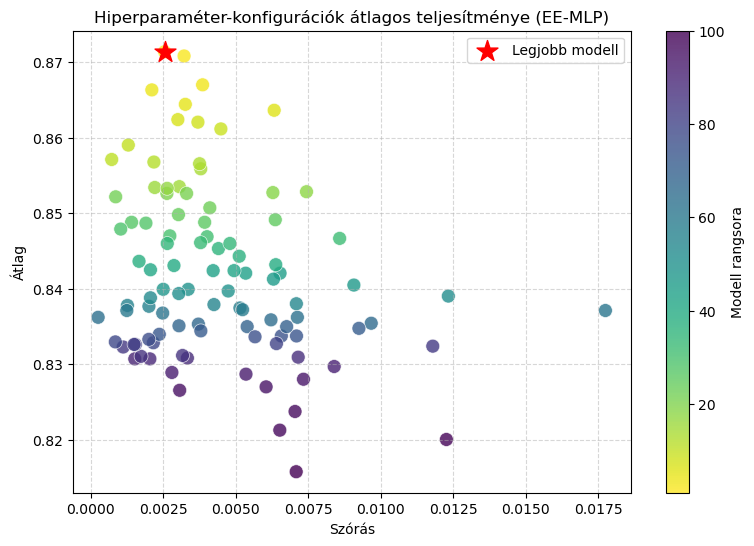

In [32]:
#minden pont a RS egy-egy állapota
#pontok száma az ábrán = n_iter
#a pontok a 3foldCV-ből számolt átlagot és szórás jelzik
#a komcsi csillag ezek közül a legjobb

#df konvertálás
cv_results = pd.DataFrame(all_cv_results)

#rangsorolás accuracy alapján (a legnagyobb a legjobb, ezért ascending=False)
cv_results['rank_test_score'] = cv_results['mean_test_acc'].rank(method='min', ascending=False)

#OPCIÓ:
# Ha inkább a loss-t kell ábrázolni az accuracy helyett, akkor a rangsor (a legkisebb a legjobb):
# cv_results['rank_test_score'] = cv_results['mean_test_loss'].rank(method='min')

plt.figure(figsize=(9, 6))

#szóródiagram:
scatter = plt.scatter(
    cv_results['std_test_acc'],   # Figyelj az oszlopnévre!
    cv_results['mean_test_acc'],  # Figyelj az oszlopnévre!
    c=cv_results['rank_test_score'],
    cmap='viridis_r', 
    alpha=0.8,
    edgecolors='w',
    linewidth=0.5,
    s=100
)

#legjobb modell (ahol a rank == 1)
best_cv_model = cv_results[cv_results['rank_test_score'] == 1].iloc[0]

plt.scatter(
    best_cv_model['std_test_acc'], 
    best_cv_model['mean_test_acc'],
    color='red', 
    marker='*', 
    s=250,
    label='Legjobb modell',
    zorder=5 
)

# Színskála (Colorbar) hozzáadása
cbar = plt.colorbar(scatter)
cbar.set_label('Modell rangsora')

# Tengelyek és címek
plt.xlabel('Szórás')
plt.ylabel('Átlag')
plt.title('Hiperparaméter-konfigurációk átlagos teljesítménye (EE-MLP)')

# Rács és jelmagyarázat
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Mentés és megjelenítés (A DATASET_NAME a korábbi kódodból jön)
plt.savefig(f'CV_alakulas_{DATASET_NAME}_javitott.png', bbox_inches='tight', dpi=300)
plt.show()

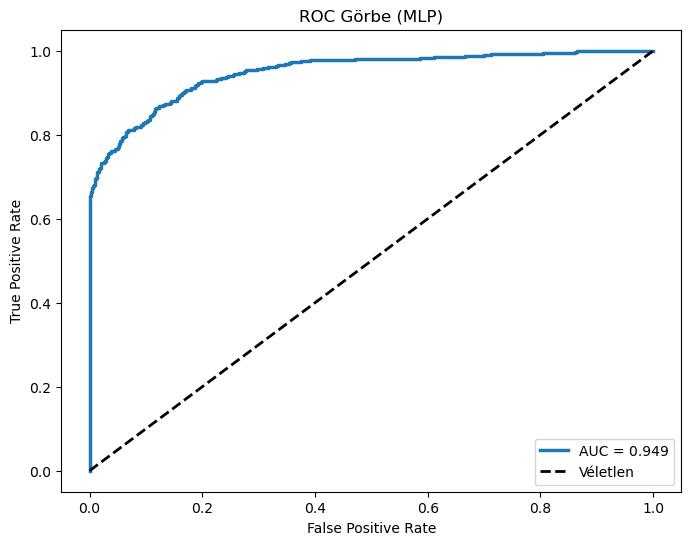

In [38]:
# ROC

plt.figure(figsize=(8,6))
fpr, tpr, _ = roc_curve(y_test, test_preds_probs)
plt.plot(fpr, tpr, linewidth=2.5, label=f"AUC = {test_auc:.3f}")
#plt.plot([0, 1], [0, 1], linestyle='k--', label='Véletlen')
plt.plot([0, 1], [0, 1], color='k', linestyle='--', lw =2, label='Véletlen')
plt.title("ROC Görbe (MLP)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig(f"roc_curve_{DATASET_NAME}.png", bbox_inches='tight', dpi=300)
plt.show()

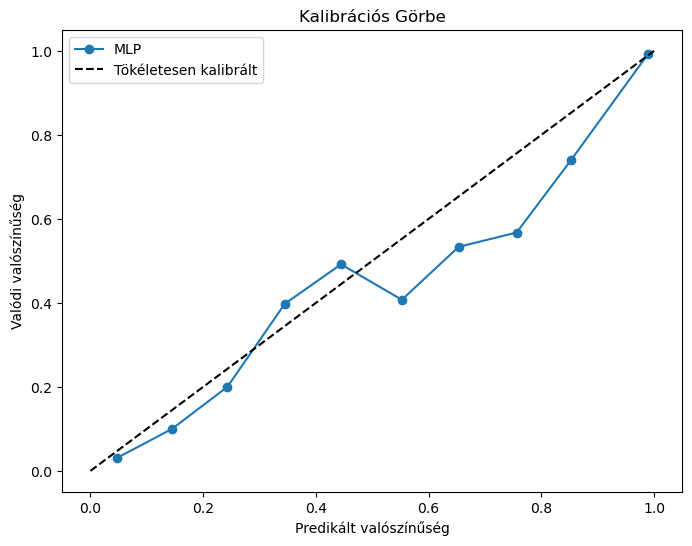

In [40]:
# Kalibrációs görbe

plt.figure(figsize=(8,6))
prob_true, prob_pred = calibration_curve(y_test, test_preds_probs, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label="MLP")
#plt.plot([0, 1], [0, 1], linestyle='k--', label="Tökéletesen kalibrált")
plt.plot([0, 1], [0, 1], color='k', linestyle='--', label='Tökéletesen kalibrált')
plt.title("Kalibrációs Görbe")
plt.xlabel('Predikált valószínűség')
plt.ylabel('Valódi valószínűség')
plt.legend()
plt.savefig(f"calibration_curve_{DATASET_NAME}.png", bbox_inches='tight', dpi=300)
plt.show()

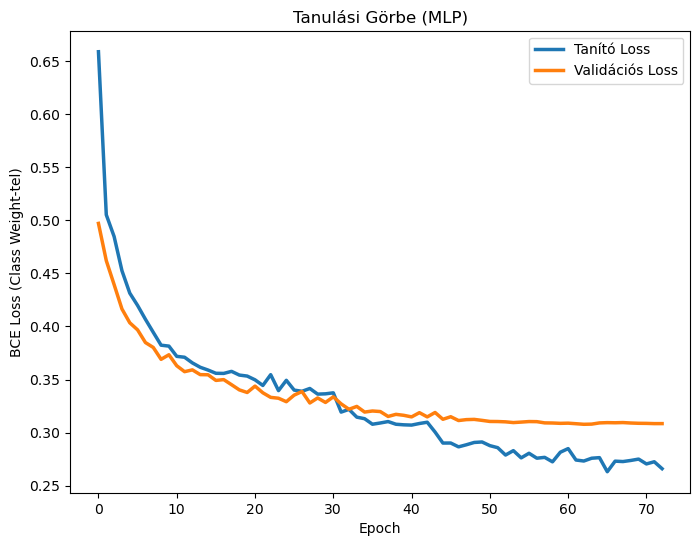

In [44]:
# Tanulási görbe

plt.figure(figsize=(8,6))
plt.plot(train_losses, linewidth = 2.5, label="Tanító Loss")
plt.plot(val_losses, linewidth = 2.5, label="Validációs Loss")
plt.title("Tanulási Görbe (MLP)")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss (Class Weight-tel)")
plt.legend()
plt.savefig(f"learning_curve_{DATASET_NAME}.png", bbox_inches='tight', dpi=300)
plt.show()

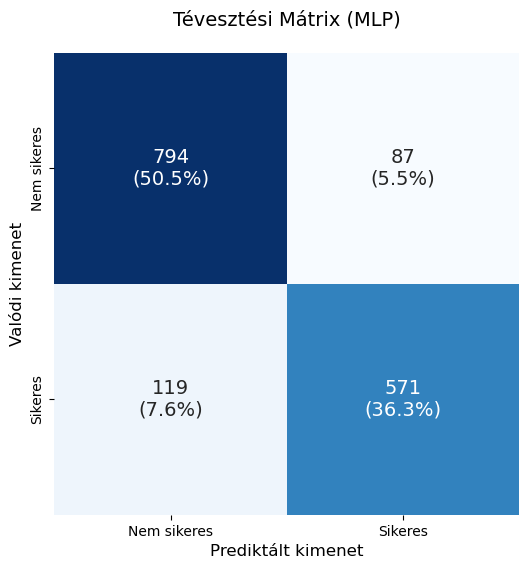

In [45]:
#Confusion matrix

cm = confusion_matrix(y_test, test_preds_binary)

cm_percentages = cm / np.sum(cm)

labels = [f"{count}\n({percent:.1%})" for count, percent in zip(cm.flatten(), cm_percentages.flatten())]
labels = np.asarray(labels).reshape(2, 2)

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Nem sikeres', 'Sikeres'],
            yticklabels=['Nem sikeres', 'Sikeres'],
            annot_kws={"size": 14}) # A betűméretet itt tudod növelni

plt.xlabel('Prediktált kimenet', fontsize=12)
plt.ylabel('Valódi kimenet', fontsize=12)
plt.title("Tévesztési Mátrix (MLP)", fontsize=14, pad=20)

plt.savefig(f"confusion_matrix_szazalekos_{DATASET_NAME}.png", bbox_inches='tight', dpi=300)
plt.show()

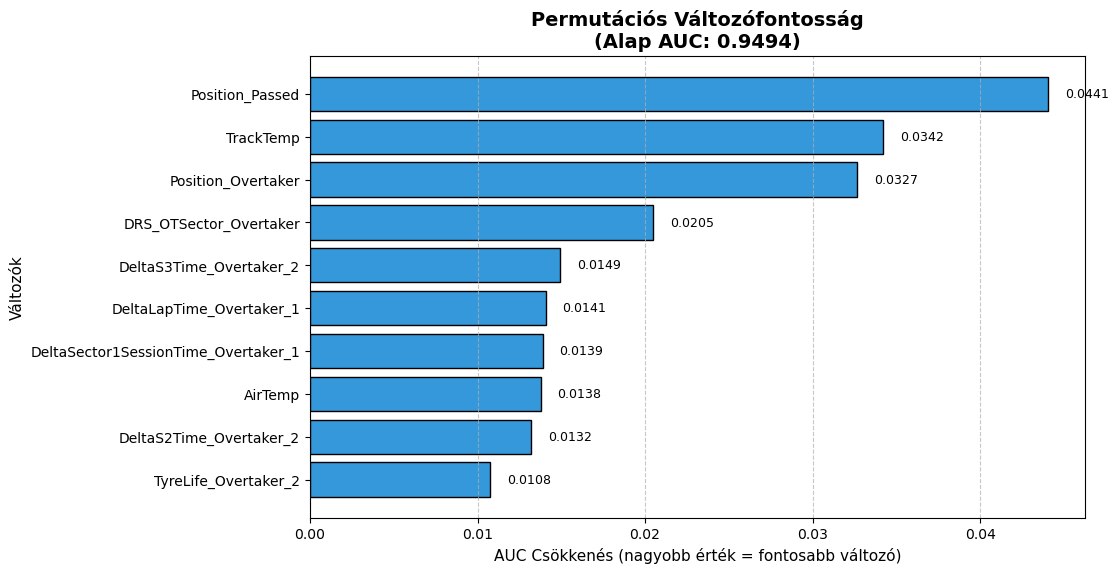

In [47]:
#Feature Importance

all_features = list(NUM_COLS) + list(CAT_COLS)

importance_df = pd.DataFrame(list(feature_importances.items()), columns=['Feature', 'Importance (AUC Drop)'])

feature_importances = {}

for i, feature_name in enumerate(all_features):
    
    #lemásoljuk az eredeti X_test tömböt, hogy a következő körre ne maradjon összekeverve
    X_test_shuffled = X_test.copy()
    
    #az oszlopok összekeverése 
    #ez megszünteti a kapcsolatot a változó és a célváltozó (Sikeres) között.
    np.random.shuffle(X_test_shuffled[:, i])
    
    #tenzorokká alakítjuk a "rontott" adatokat pontosan úgy, ahogy a tesztelésnél
    test_num_shuff = torch.FloatTensor(X_test_shuffled[:, :len(NUM_COLS)].astype(float)).to(DEVICE)
    test_cat_shuff = torch.LongTensor(X_test_shuffled[:, len(NUM_COLS):].astype(int)).to(DEVICE)
    
    #predikció a megkevert adatokkal
    best_model.eval()
    with torch.no_grad():
        shuffled_preds = best_model(test_num_shuff, test_cat_shuff)
        shuffled_preds_probs = shuffled_preds.cpu().numpy()
        
    #új AUC kiszámítása a rontott predikciókkal
    shuffled_auc = roc_auc_score(y_test, shuffled_preds_probs)
    
    #FONTOSSÁG = Alap AUC - Rontott AUC
    #minél nagyobb ez a szám, annál többet esett a modell teljesítménye, tehát annál FONTOSABB volt az a változó!
    importance_score = test_auc - shuffled_auc
    feature_importances[feature_name] = importance_score


importance_df = importance_df.sort_values(by='Importance (AUC Drop)', ascending=True).tail(10)

# 9. Vizualizáció
plt.figure(figsize=(10, 6)) # Fix méret, mivel már csak 10 elemet rajzolunk

# Vízszintes oszlopdiagram
bars = plt.barh(importance_df['Feature'], importance_df['Importance (AUC Drop)'], color='#3498db', edgecolor='black')

plt.xlabel('AUC Csökkenés (nagyobb érték = fontosabb változó)', fontsize=11)
plt.ylabel('Változók', fontsize=11)
plt.title(f'Permutációs Változófontosság\n(Alap AUC: {test_auc:.4f})', fontsize=14, fontweight='bold')

# Függőleges rácsvonalak a könnyebb olvashatóságért
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Az értékek kiírása az oszlopok végére
for bar in bars:
    width = bar.get_width()
    # Ha a fontosság negatív lenne (nagyon ritka, de előfordul zajos változóknál), akkor is kiírja
    label_x = width + 0.001 if width > 0 else width - 0.001
    ha = 'left' if width > 0 else 'right'
    plt.text(label_x, bar.get_y() + bar.get_height()/2, f'{width:.4f}', 
             va='center', ha=ha, fontsize=9)

# Kimentés png-ként a pipeline logikája alapján
plt.savefig(f'Feature_Importance_{DATASET_NAME}.png', bbox_inches='tight', dpi=300)
plt.show()